In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'Songti SC'

### 导入数据

In [2]:
movies =  pd.read_excel(r"C:\Users\桃花林\Desktop\数据分析\实战项目\豆瓣Top250\豆瓣Top250.xlsx")
movies.head()

,排名,电影名,评分,评价人数,导演,年份,国家,类型,主演
0,1,肖申克的救赎,9.7,3269693,弗兰克·德拉邦特 Frank Darabont,1994,美国,犯罪 剧情,蒂姆·罗宾斯 Tim Robbins /...
1,2,霸王别姬,9.6,2411970,陈凯歌 Kaige Chen,1993,中国大陆 中国香港,剧情 爱情 同性,张国荣 Leslie Cheung / 张丰毅 Fengyi Zha...
2,3,泰坦尼克号,9.5,2486242,詹姆斯·卡梅隆 James Cameron,1997,美国,剧情 爱情 灾难,莱昂纳多·迪卡普里奥 Leonardo...
3,4,阿甘正传,9.5,2420134,罗伯特·泽米吉斯 Robert Zemeckis,1994,美国,剧情 爱情,汤姆·汉克斯 Tom Hanks / ...
4,5,千与千寻,9.4,2524719,宫崎骏 Hayao Miyazaki,2001,日本,剧情 动画 奇幻,柊瑠美 Rumi Hîragi / 入野自由 Miy...


### 数据清洗

In [3]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   排名      250 non-null    int64  
 1   电影名     250 non-null    object 
 2   评分      250 non-null    float64
 3   评价人数    250 non-null    int64  
 4   导演      250 non-null    object 
 5   年份      250 non-null    object 
 6   国家      250 non-null    object 
 7   类型      250 non-null    object 
 8   主演      238 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 17.7+ KB


In [4]:
# 查找缺失值
movies.loc[movies['主演'].isnull()==True]

,排名,电影名,评分,评价人数,导演,年份,国家,类型,主演
22,23,触不可及,9.3,1289307,奥利维·那卡什 Olivier Nakache / 艾力克·托兰达 Eric Toledan...,2011,法国,剧情 喜剧,NaN
53,54,黑客帝国,9.1,946425,安迪·沃卓斯基 Andy Wachowski / 拉娜·沃卓斯基 Lana Wachowsk...,1999,美国,动作 科幻,NaN
68,69,窃听风暴,9.2,630154,弗洛里安·亨克尔·冯·多纳斯马尔克 Florian Henckel von Donnersm...,2006,德国,剧情 悬疑,NaN
79,80,蝴蝶效应,8.9,1064735,埃里克·布雷斯 Eric Bress / J·麦基·格鲁伯 J. Mackye Gruber...,2004,美国 加拿大,剧情 悬疑 科幻 惊悚,NaN
114,115,头脑特工队,8.8,804386,彼特·道格特 Pete Docter / 罗纳尔多·德尔·卡门 Ronaldo Del Ca...,2015,美国,喜剧 动画 冒险,NaN
167,168,黑客帝国3：矩阵革命,8.8,497390,拉娜·沃卓斯基 Lana Wachowski / 莉莉·沃卓斯基 Lilly Wachows...,2003,美国,动作 科幻,NaN
176,177,疯狂原始人,8.7,921385,科克·德·米科 Kirk De Micco / 克里斯·桑德斯 Chris Sanders ...,2013,美国,喜剧 动画 冒险,NaN
184,185,上帝之城,9.0,333501,费尔南多·梅里尔斯 Fernando Meirelles / 卡迪亚·兰德 Kátia Lu...,2002,巴西 法国,犯罪 剧情,NaN
195,196,冰川时代,8.7,686168,卡洛斯·沙尔丹哈 Carlos Saldanha / 克里斯·韦奇 Chris Wedge ...,2002,美国,喜剧 动画 冒险,NaN
222,223,初恋这件小事,8.5,1052125,普特鹏·普罗萨卡·那·萨克那卡林 Puttipong Promsaka Na Sakolna...,2010,泰国,剧情 喜剧 爱情,NaN


In [5]:
movies['年份'] = movies['年份'].astype(str)
movies['年份'] = movies['年份'].str.extract(r'(\d{4})')
movies['年份'] = pd.to_numeric(movies['年份'], errors='coerce')

In [6]:
# 清洗：移除末尾的 ... 及其前导斜杠/空格
movies['主演_clean'] = movies['主演'].fillna('').astype(str).str.replace(r'(\s*/)?\s*\.\.\.$', '', regex=True)

In [ ]:
# 提取导演，主演中的中文部分
import re
def clean_directors(series):
    def clean_one(entry):
        if pd.isna(entry):
            return ''
        parts = str(entry).split('/')
        cleaned_parts = []
        for part in parts:
            chinese = re.search(r'[\u4e00-\u9fff·]+', part)
            if chinese:
                cleaned_parts.append(chinese.group().strip())
            else:
                # 如果没有中文，保留原部分（去除首尾空格）
                cleaned_parts.append(part.strip())
        return '/'.join(cleaned_parts)

    return series.apply(clean_one)

movies['导演_clean'] = clean_directors(movies['导演'])
movies['主演_clean2'] = clean_directors(movies['主演_clean'])

In [10]:
movies.drop(columns=['导演', '主演', '主演_clean'], inplace=True)
movies.rename(columns={'导演_clean':'导演','主演_clean2':'主演'}, inplace=True)

In [11]:
movies.head()

,排名,电影名,评分,评价人数,年份,国家,类型,导演,主演
0,1,肖申克的救赎,9.7,3269693,1994,美国,犯罪 剧情,弗兰克·德拉邦特,蒂姆·罗宾斯
1,2,霸王别姬,9.6,2411970,1993,中国大陆 中国香港,剧情 爱情 同性,陈凯歌,张国荣/张丰毅
2,3,泰坦尼克号,9.5,2486242,1997,美国,剧情 爱情 灾难,詹姆斯·卡梅隆,莱昂纳多·迪卡普里奥
3,4,阿甘正传,9.5,2420134,1994,美国,剧情 爱情,罗伯特·泽米吉斯,汤姆·汉克斯
4,5,千与千寻,9.4,2524719,2001,日本,剧情 动画 奇幻,宫崎骏,柊瑠美/入野自由


### 问题1：什么类型的电影上榜数量最多

In [12]:
all_type = set()
for item in movies['类型']:
    all_type.update(item.split(' '))

In [13]:
all_type

{'传记',
 '儿童',
 '冒险',
 '剧情',
 '动作',
 '动画',
 '历史',
 '古装',
 '同性',
 '喜剧',
 '奇幻',
 '家庭',
 '恐怖',
 '悬疑',
 '情色',
 '惊悚',
 '战争',
 '歌舞',
 '武侠',
 '灾难',
 '爱情',
 '犯罪',
 '科幻',
 '纪录片',
 '西部',
 '运动',
 '音乐'}

In [14]:
type_df = pd.DataFrame()
for item in all_type:
    type_df[item] = movies['类型'].str.contains(item).map(lambda x : 1 if x else 0)

In [16]:
# type_df
type_df.sum().sort_values(ascending=False)

剧情     186
爱情      55
喜剧      53
冒险      50
奇幻      44
犯罪      41
动画      40
惊悚      33
悬疑      31
动作      31
科幻      25
家庭      18
传记      15
战争      14
历史      10
古装      10
同性       9
音乐       9
歌舞       7
儿童       4
武侠       4
情色       3
灾难       2
西部       2
恐怖       2
纪录片      1
运动       1
dtype: int64

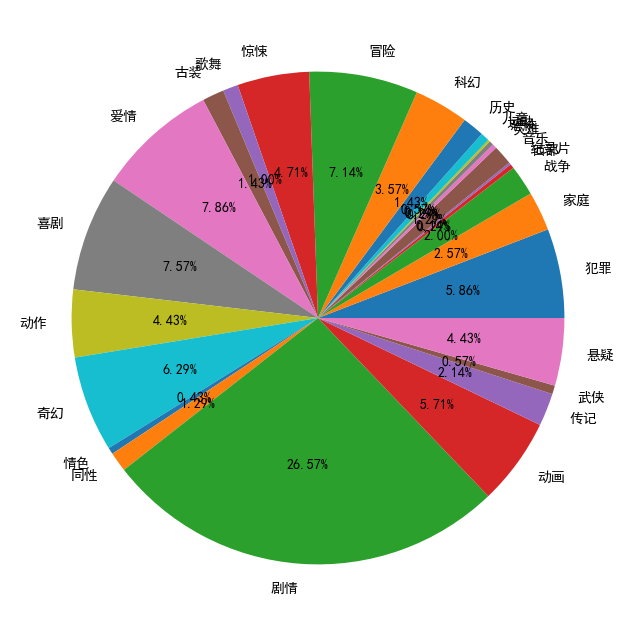

In [17]:
# matplotlib绘制饼状图
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows系统用黑体；Mac用['Arial Unicode MS']；Linux用['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题
plt.figure(figsize=(8,8),dpi=100)
x = type_df.sum().values.tolist()
labels = type_df.sum().index.tolist()
plt.pie(x,labels=labels,autopct="%.2f%%")
plt.show()

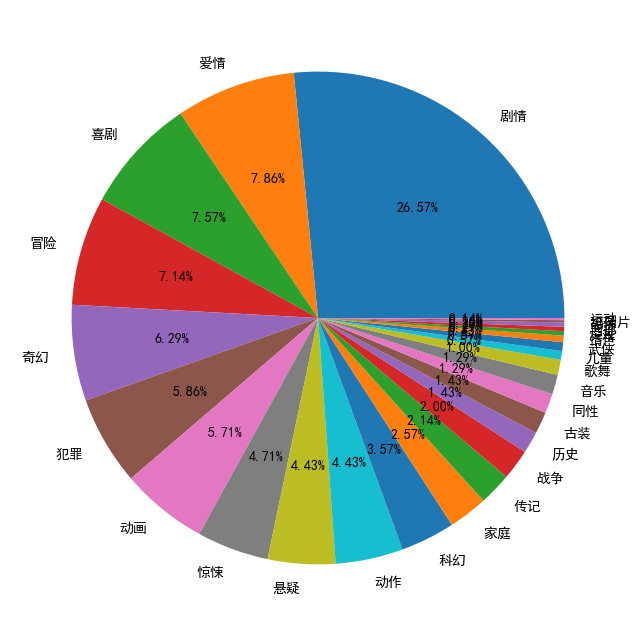

In [18]:
# pandas绘制饼状图
plt.figure(figsize=(8,8),dpi=100)
type_df.sum().sort_values(ascending=False).plot.pie(autopct='%.2f%%')
plt.show()

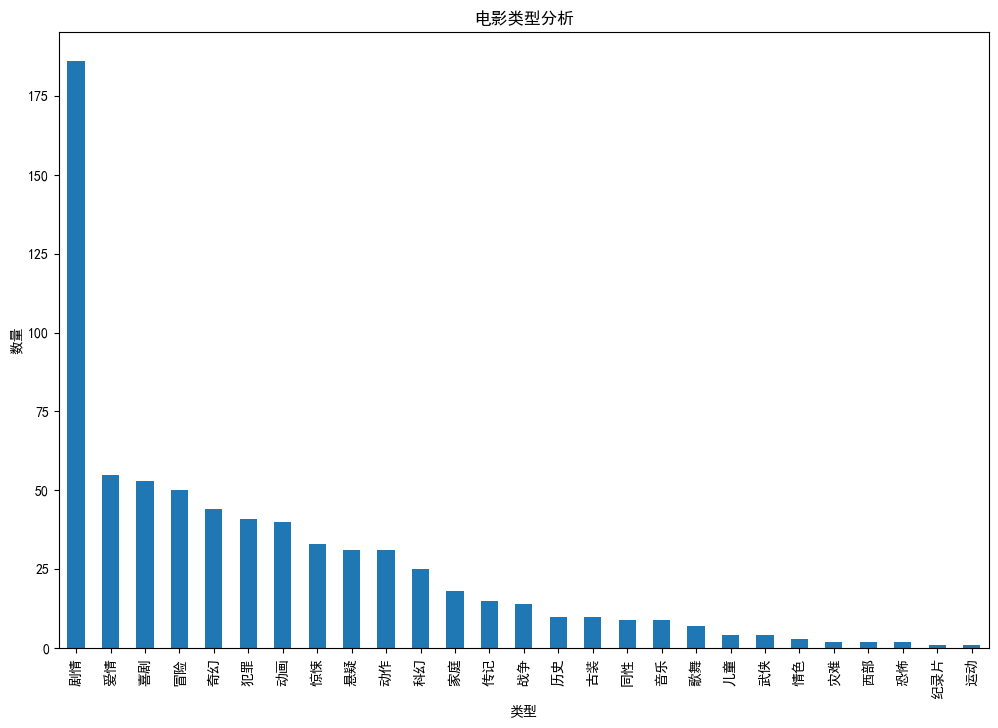

In [ ]:
# pandas绘制柱状图
plt.figure(figsize=(12,8),dpi=100)
type_df.sum().sort_values(ascending=False).plot.bar()
plt.title('电影类型分析')
plt.xlabel('类型')
plt.ylabel('数量')
plt.show()

### 哪些年份的电影上榜数量最多

In [20]:
movies['年份']

0      1994
1      1993
2      1997
3      1994
4      2001
       ... 
245    2016
246    2016
247    1940
248    2017
249    2015
Name: 年份, Length: 250, dtype: int64

In [21]:
year_df = pd.value_counts(movies['年份']).sort_values(ascending=False)

C:\Users\桃花林\AppData\Local\Temp\ipykernel_57784\3705706808.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  year_df = pd.value_counts(movies['年份']).sort_values(ascending=False)


<Axes: xlabel='年份'>

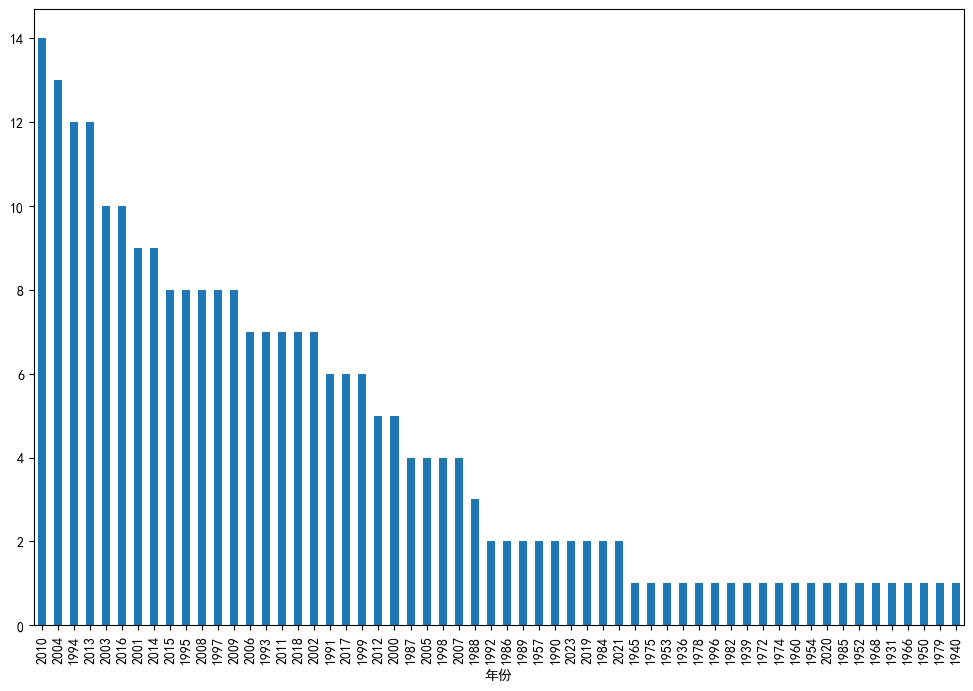

In [22]:
# 绘制柱状图
plt.figure(figsize=(12,8),dpi=100)
year_df.plot.bar()

In [23]:
# 绘制折线图
year_df = pd.value_counts(movies['年份'])

C:\Users\桃花林\AppData\Local\Temp\ipykernel_57784\3207325864.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  year_df = pd.value_counts(movies['年份'])


In [26]:
year_df =  year_df.sort_index(axis=0)
year_df

年份
1931     1
1936     1
1939     1
1940     1
1950     1
1952     1
1953     1
1954     1
1957     2
1960     1
1965     1
1966     1
1968     1
1972     1
1974     1
1975     1
1978     1
1979     1
1982     1
1984     2
1985     1
1986     2
1987     4
1988     3
1989     2
1990     2
1991     6
1992     2
1993     7
1994    12
1995     8
1996     1
1997     8
1998     4
1999     6
2000     5
2001     9
2002     7
2003    10
2004    13
2005     4
2006     7
2007     4
2008     8
2009     8
2010    14
2011     7
2012     5
2013    12
2014     9
2015     8
2016    10
2017     6
2018     7
2019     2
2020     1
2021     2
2023     2
Name: count, dtype: int64

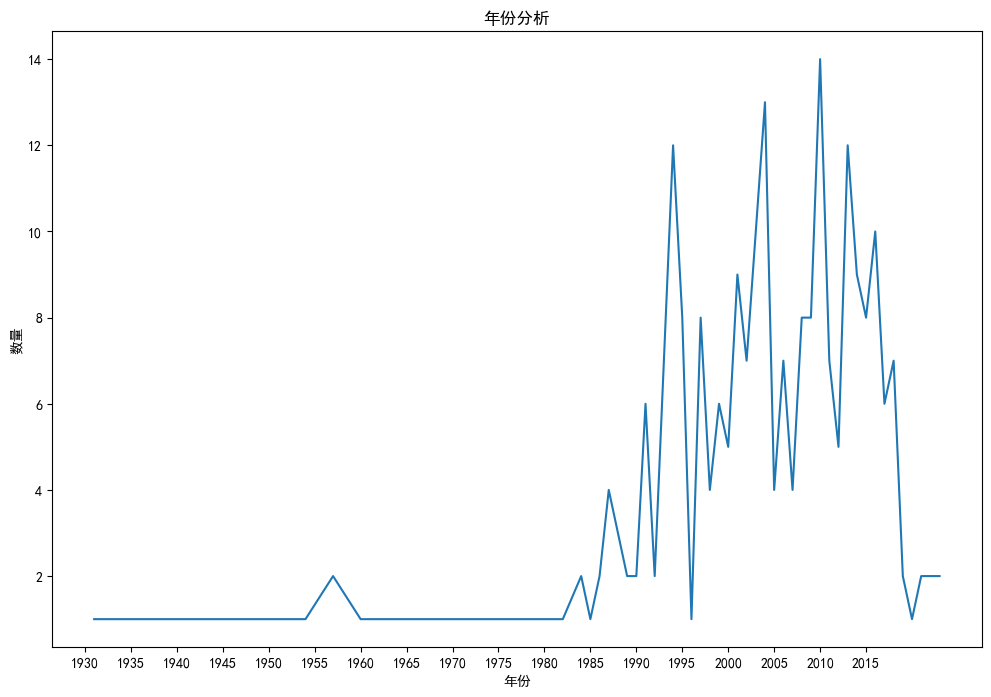

In [27]:
plt.figure(figsize=(12,8),dpi=100)
plt.xlabel('年份')
plt.ylabel('数量')
plt.title('年份分析')

year_df.plot(xticks=range(1930,2020,5))
plt.show()

### 哪些国家和地区的电影上榜最多

In [28]:
all_countries = set()
for item in movies['国家']:
    all_countries.update(item.split(' '))

In [29]:
country_df = pd.DataFrame()
for item in all_countries:
    country_df[item] = movies['国家'].str.contains(item).map(lambda x : 1 if x else 0)

In [30]:
country_df = country_df.sum().sort_values(ascending=False).iloc[0:10]

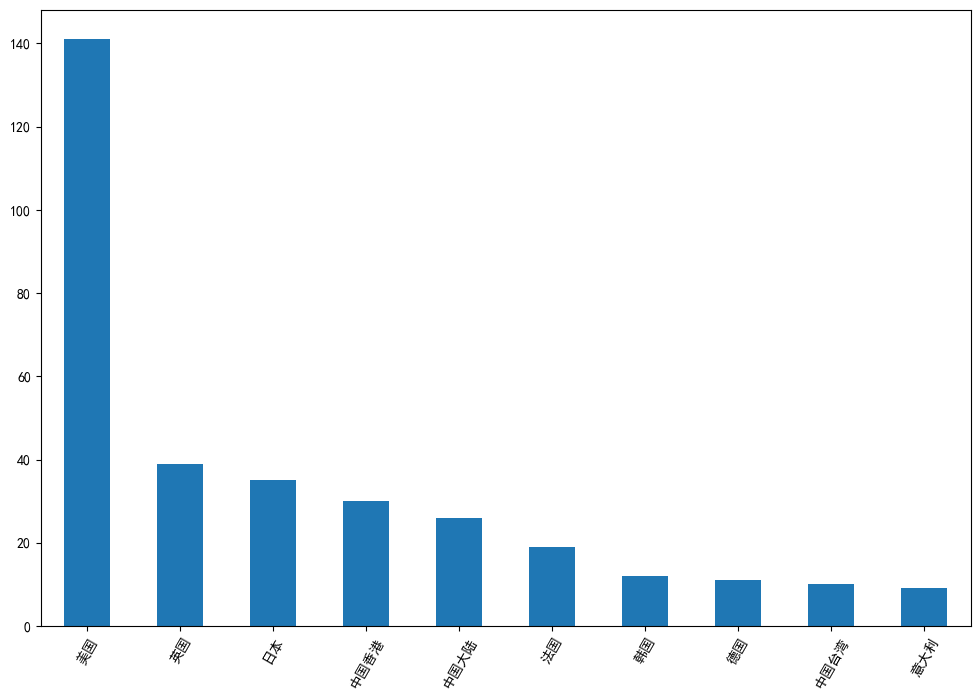

In [31]:
plt.figure(figsize=(12,8),dpi=100)
country_df.plot.bar()
plt.xticks(rotation=60)
plt.show()

### 上榜最多的导演和演员

In [32]:
def field_sum(field):
    all_set = set()
    for item in movies[field]:
        all_set.update(item.split('/'))

    new_df = pd.DataFrame()
    for item in all_set:
        new_df[item] = movies[field].str.contains(item).map(lambda x : 1 if x else 0)
    
    return new_df

In [33]:
director_df = field_sum('导演')

C:\Users\桃花林\AppData\Local\Temp\ipykernel_57784\1907430024.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[item] = movies[field].str.contains(item).map(lambda x : 1 if x else 0)
C:\Users\桃花林\AppData\Local\Temp\ipykernel_57784\1907430024.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  new_df[item] = movies[field].str.contains(item).map(lambda x : 1 if x else 0)
C:\Users\桃花林\AppData\Local\Temp\ipykernel_57784\1907430024.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 

In [34]:
director_df.sum().sort_values(ascending=False)

宫崎骏          8
史蒂文·斯皮尔伯格    6
克里斯托弗·诺兰     6
李安           5
王家卫          4
            ..
克林特·伊斯特伍德    1
斯蒂芬·卓博斯基     1
藤森雅也         1
斯坦利·库布里克     1
亚当·艾略特       1
Length: 195, dtype: int64

In [35]:
director_df = director_df.sum().sort_values(ascending=False).iloc[0:10]

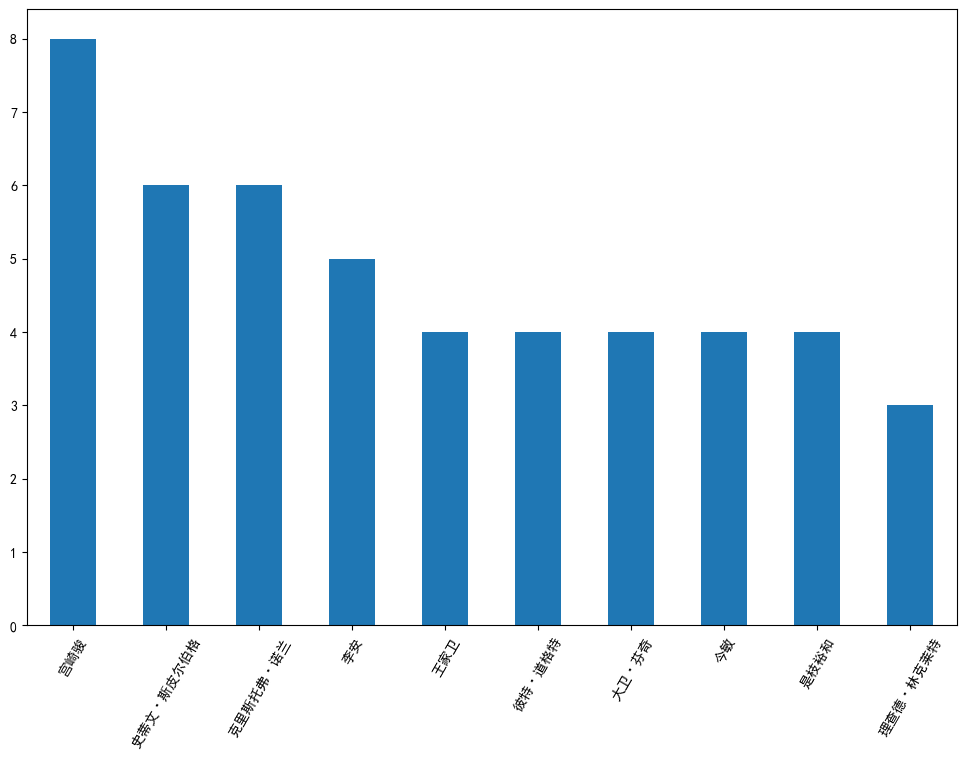

In [36]:
plt.figure(figsize=(12,8),dpi=100)
director_df.plot.bar()
plt.xticks(rotation=60)
plt.show()

In [37]:
actor_df = movies['主演'].str.get_dummies(sep='/')
actor_df

,Dakota Fanning,Daniel Radcliffe,Emma Watson,Mi,Rupert Grint,Sean Penn,丁建华,三浦贵大,三船敏郎,上,...,马修·麦康纳,马特·达蒙,马精武,马西,马里奥·卡萨斯,马龙·白兰度,高山南,麦斯·米科尔森,黎明,默罕默德·阿米尔·纳吉
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
247,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
248,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
actor_df.sum().sort_values(ascending=False)

周星驰            6
丹尼尔·雷德克里夫      6
梁朝伟            5
汤姆·汉克斯         5
莱昂纳多·迪卡普里奥     5
              ..
希斯·莱杰          1
布鲁斯·威利斯        1
布拉             1
布丽·拉尔森         1
默罕默德·阿米尔·纳吉    1
Length: 310, dtype: int64

In [39]:
actor_df = actor_df.sum().sort_values(ascending=False).iloc[0:10]

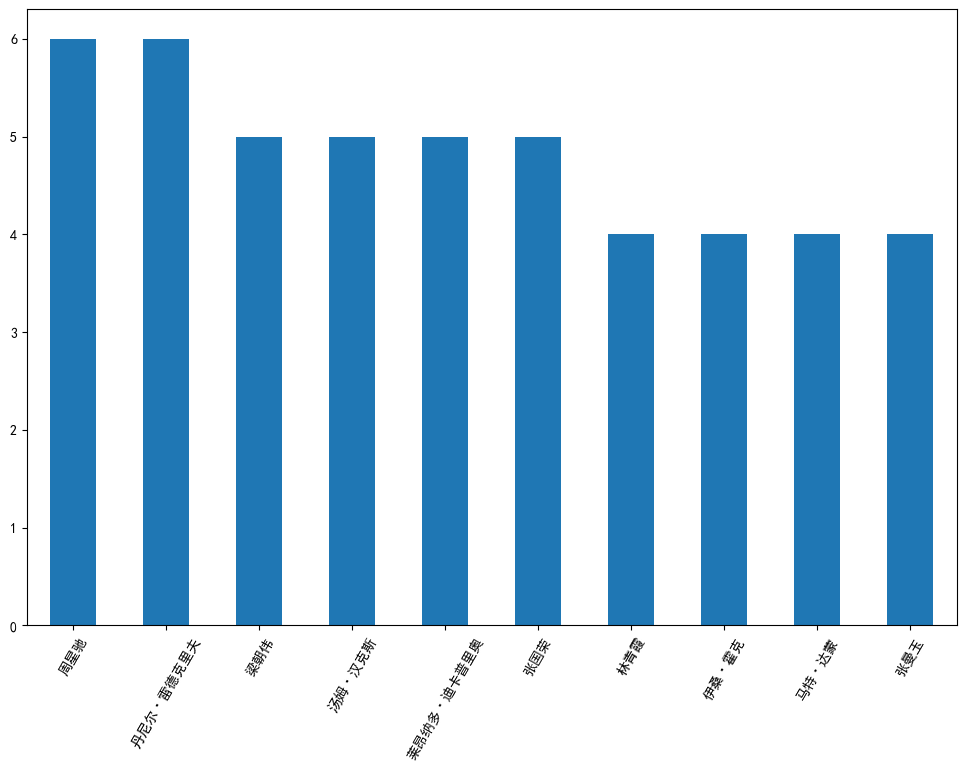

In [40]:
plt.figure(figsize=(12,8),dpi=100)
actor_df.plot.bar()
plt.xticks(rotation=60)
plt.show()

### 评分和评价人数之间的关系

In [41]:
movies.columns

Index(['排名', '电影名', '评分', '评价人数', '年份', '国家', '类型', '导演', '主演'], dtype='object')

In [42]:
movies['评分'] = movies['评分'].astype('int64')

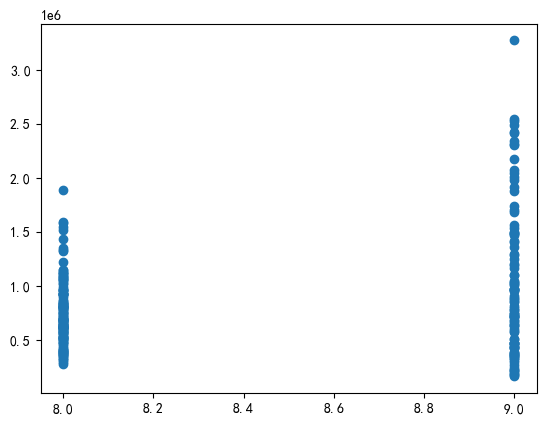

In [44]:
plt.scatter(movies['评分'],movies['评价人数'])
plt.show()

In [45]:
movies['评分'].corr(movies['评价人数'])

np.float64(0.24384592808078684)